# Análise de Fairness Estratificada — Modelos de Prognóstico de Dengue

Avalia se a performance preditiva dos modelos treinados é equânime entre subgrupos
populacionais relevantes. Métricas calculadas com IC 95% via bootstrap não paramétrico
(1.000 reamostragens, `random_state=42`).

**Conjunto de teste:** 2024 (n = 160.534; 5.295 óbitos; prevalência = 3,3%)  
**Threshold fixo:** 0,5  
**Limiar de alerta:** ΔAUPRC > 0,05 entre melhor e pior subgrupo

**Variáveis de estratificação:**
1. Faixa etária (`age_years`)
2. Sexo (`CS_SEXO`)
3. Raça/cor (`CS_RACA`)
4. Escolaridade (`CS_ESCOL_N`)
5. Gestação (`CS_GESTANT`)
6. Região geográfica (`SG_UF`)

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score

# Caminhos relativos ao notebook em notebooks/06_fairness/
DATA_DIR   = '../../data/features/baseline'
OUTPUT_MET = '../../output/metricas'
OUTPUT_PLT = '../../output/plots'
os.makedirs(OUTPUT_PLT, exist_ok=True)

# Parâmetros globais
THRESHOLD   = 0.5
N_BOOT      = 2000
RANDOM_STATE = 42
MIN_EVENTOS  = 30  # mínimo de eventos positivos por subgrupo para inclusão

LABEL_MAP = {
    'logistic_regression_baseline_tuned': 'LR (tuned)',
    'lightgbm_baseline_tuned':            'LightGBM (tuned)',
    'xgboost_baseline_tuned':             'XGBoost (tuned)',
    'random_forest_baseline':             'RF',
    'decision_tree_baseline':       'DT',
}

print(f'{len(LABEL_MAP)} modelos configurados.')

5 modelos configurados.


In [2]:
# Carregar X_test com variáveis originais (antes do pré-processamento)
X_test = pd.read_parquet(os.path.join(DATA_DIR, 'X_test.parquet'))
y_test = pd.read_parquet(os.path.join(DATA_DIR, 'y_test.parquet')).squeeze()

# Corrigir outliers de idade (consistente com o pré-processamento dos modelos)
X_test = X_test.copy()
X_test.loc[X_test['age_years'] > 120, 'age_years'] = np.nan

# Base de fairness: variáveis de estratificação + target
df_test = X_test[['age_years', 'CS_SEXO', 'CS_RACA', 'CS_ESCOL_N', 'CS_GESTANT', 'SG_UF']].copy()
df_test['y_true'] = y_test.values

# Carregar predições de cada modelo (alinhadas por posição com X_test)
modelos_ok = []
for arq, label in LABEL_MAP.items():
    pred_path = os.path.join(OUTPUT_MET, f'{arq}_predicoes.parquet')
    if not os.path.exists(pred_path):
        print(f'AVISO: predições não encontradas — {label}')
        continue
    preds = pd.read_parquet(pred_path)
    df_test[f'proba_{arq}'] = preds['y_proba'].values
    modelos_ok.append(label)

# Dicionário: rótulo → coluna de probabilidade
MODELO_COLS = {label: f'proba_{arq}'
               for arq, label in LABEL_MAP.items()
               if f'proba_{arq}' in df_test.columns}

print(f'Conjunto de teste: {len(df_test):,} registros')
print(f'Eventos (óbitos): {int(df_test["y_true"].sum()):,} ({df_test["y_true"].mean()*100:.2f}%)')
print(f'Modelos carregados: {len(MODELO_COLS)} / {len(LABEL_MAP)}')
df_test.head(3)

Conjunto de teste: 160,534 registros
Eventos (óbitos): 5,295 (3.30%)
Modelos carregados: 5 / 5


,age_years,CS_SEXO,CS_RACA,CS_ESCOL_N,CS_GESTANT,SG_UF,y_true,proba_logistic_regression_baseline_tuned,proba_lightgbm_baseline_tuned,proba_xgboost_baseline_tuned,proba_random_forest_baseline,proba_decision_tree_baseline
0,43.0,F,1.0,8.0,5.0,31,0.0,0.187332,0.088237,0.139759,0.068952,0.234593
1,50.0,F,4.0,3.0,5.0,31,0.0,0.176907,0.209854,0.267208,0.037447,0.095364
2,73.0,M,NaN,NaN,6.0,31,0.0,0.779750,0.723708,0.772283,0.416726,0.407799


In [3]:
def calcular_secao(df, grupos_col, varname, n_boot=N_BOOT):
    """
    Bootstrap não paramétrico para todos os modelos em cada subgrupo.
    Índices de reamostragem compartilhados entre modelos no mesmo subgrupo.
    Subgrupos com menos de MIN_EVENTOS eventos são excluídos com aviso.
    """
    subgrupos = sorted(df[grupos_col].dropna().unique())
    rows = []

    for sg in subgrupos:
        mask    = df[grupos_col] == sg
        subset  = df[mask].reset_index(drop=True)
        n_total   = len(subset)
        n_eventos = int(subset['y_true'].sum())

        if n_eventos < MIN_EVENTOS:
            print(f'  [EXCLUÍDO] {varname} = {sg!r}: apenas {n_eventos} eventos (< {MIN_EVENTOS})')
            continue

        print(f'  Subgrupo {sg!r}: n={n_total:,}, eventos={n_eventos}', end=' ... ')

        # Índices bootstrap: gerados uma vez, compartilhados entre modelos
        rng      = np.random.RandomState(RANDOM_STATE)
        idx_boot = rng.randint(0, n_total, (n_boot, n_total))
        y_true   = subset['y_true'].values

        for label, col in MODELO_COLS.items():
            if col not in subset.columns:
                continue
            y_proba = subset[col].values

            boot = {'auprc': [], 'roc': [], 'sens': [], 'esp': []}
            for idx in idx_boot:
                yt, yp = y_true[idx], y_proba[idx]
                if yt.sum() < 2 or (yt == 0).sum() < 2:
                    continue
                yb = (yp >= THRESHOLD).astype(int)
                tp = ((yt == 1) & (yb == 1)).sum()
                fp = ((yt == 0) & (yb == 1)).sum()
                fn = ((yt == 1) & (yb == 0)).sum()
                tn = ((yt == 0) & (yb == 0)).sum()
                boot['auprc'].append(average_precision_score(yt, yp))
                boot['roc'].append(roc_auc_score(yt, yp))
                boot['sens'].append(tp / (tp + fn) if (tp + fn) > 0 else 0)
                boot['esp'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)

            def ci(v): return np.percentile(v, 2.5), np.mean(v), np.percentile(v, 97.5)
            la, ma, ha = ci(boot['auprc'])
            lr, mr, hr = ci(boot['roc'])
            ls, ms, hs = ci(boot['sens'])
            le, me, he = ci(boot['esp'])

            rows.append({
                'subgrupo':   str(sg),
                'modelo':     label,
                'n_total':    n_total,
                'n_eventos':  n_eventos,
                'auprc':          ma, 'auprc_ci_low':   la, 'auprc_ci_high':   ha,
                'roc_auc':        mr, 'roc_auc_ci_low': lr, 'roc_auc_ci_high': hr,
                'sensibilidade':  ms, 'sens_ci_low':    ls, 'sens_ci_high':    hs,
                'especificidade': me, 'esp_ci_low':     le, 'esp_ci_high':     he,
            })
        print('OK')

    return pd.DataFrame(rows)


def tabela_ic(df_sec, metrica='auprc'):
    """Tabela formatada: linhas=modelos, colunas=subgrupos, valor= 'val (lo–hi)'."""
    # calcular_secao usa nomes abreviados para sens/esp — mapeamento explícito
    CI_MAP = {
        'auprc':          ('auprc_ci_low',   'auprc_ci_high'),
        'roc_auc':        ('roc_auc_ci_low', 'roc_auc_ci_high'),
        'sensibilidade':  ('sens_ci_low',    'sens_ci_high'),
        'especificidade': ('esp_ci_low',     'esp_ci_high'),
    }
    ci_lo, ci_hi = CI_MAP.get(metrica, (f'{metrica}_ci_low', f'{metrica}_ci_high'))
    modelos   = list(MODELO_COLS.keys())
    subgrupos = sorted(df_sec['subgrupo'].unique())
    rows = {}
    for mod in modelos:
        sub = df_sec[df_sec['modelo'] == mod].set_index('subgrupo')
        row = {}
        for sg in subgrupos:
            if sg in sub.index:
                v, lo, hi = sub.loc[sg, metrica], sub.loc[sg, ci_lo], sub.loc[sg, ci_hi]
                row[sg] = f'{v:.3f} ({lo:.3f}–{hi:.3f})'
            else:
                row[sg] = '—'
        rows[mod] = row
    return pd.DataFrame(rows).T


def grafico_auprc(df_sec, titulo, filename):
    """Barras agrupadas: subgrupos no eixo-x, cores por modelo, IC 95% como error bar."""
    subgrupos = sorted(df_sec['subgrupo'].unique())
    modelos   = list(MODELO_COLS.keys())
    n_sg, n_mod = len(subgrupos), len(modelos)
    width = 0.8 / n_mod
    x = np.arange(n_sg)
    cmap = plt.get_cmap('tab20')

    fig, ax = plt.subplots(figsize=(max(11, n_sg * 1.8), 5))
    for i, mod in enumerate(modelos):
        sub  = df_sec[df_sec['modelo'] == mod].set_index('subgrupo')
        vals = [sub.loc[sg, 'auprc']          if sg in sub.index else np.nan for sg in subgrupos]
        lo   = [sub.loc[sg, 'auprc_ci_low']   if sg in sub.index else np.nan for sg in subgrupos]
        hi   = [sub.loc[sg, 'auprc_ci_high']  if sg in sub.index else np.nan for sg in subgrupos]
        err  = [[v - l if not (np.isnan(v) or np.isnan(l)) else 0 for v, l in zip(vals, lo)],
                [h - v if not (np.isnan(v) or np.isnan(h)) else 0 for h, v in zip(hi, vals)]]
        offset = (i - n_mod / 2 + 0.5) * width
        ax.bar(x + offset, vals, width * 0.9, label=mod,
               color=cmap(i / n_mod), alpha=0.82,
               yerr=err, error_kw={'elinewidth': 0.7, 'capsize': 1.5, 'alpha': 0.6})

    ax.set_xticks(x)
    ax.set_xticklabels(subgrupos, rotation=18, ha='right', fontsize=9)
    ax.set_ylabel('AUPRC', fontsize=10)
    ylim_hi = min(1.0, df_sec['auprc_ci_high'].max() * 1.18)
    ax.set_ylim(max(0, df_sec['auprc'].min() * 0.85), ylim_hi)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7.5,
              title='Modelo', title_fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    path = os.path.join(OUTPUT_PLT, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gráfico salvo: {path}')


def alertas_disparidade(df_sec, varname, limiar=0.05):
    """Identifica modelos com ΔAUPRC > limiar entre melhor e pior subgrupo."""
    alertas = []
    for mod, grp in df_sec.groupby('modelo'):
        amax = grp['auprc'].max(); amin = grp['auprc'].min()
        disp = amax - amin
        sg_max = grp.loc[grp['auprc'].idxmax(), 'subgrupo']
        sg_min = grp.loc[grp['auprc'].idxmin(), 'subgrupo']
        alertas.append({
            'modelo': mod, 'variavel': varname,
            'auprc_max': amax, 'subg_max': sg_max,
            'auprc_min': amin, 'subg_min': sg_min,
            'disparidade': disp,
            'flag': 'ALERTA' if disp > limiar else 'OK',
        })
    df_al = pd.DataFrame(alertas).sort_values('disparidade', ascending=False)
    flagged = df_al[df_al['flag'] == 'ALERTA']
    print(f'Limiar ΔAUPRC > {limiar} | {len(flagged)} modelo(s) com alerta:')
    for _, r in flagged.iterrows():
        print(f"  ⚠️  {r['modelo']}: ΔAUPRC = {r['disparidade']:.4f}  "
              f"[{r['subg_max']} ({r['auprc_max']:.3f}) vs {r['subg_min']} ({r['auprc_min']:.3f})]")
    if flagged.empty:
        print('  Nenhum modelo excede o limiar.')
    return df_al

# Dicionário global para agregar disparidades na seção final
_disparidades = {}

print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 1. Faixa Etária

A idade é um dos principais determinantes de risco de óbito por dengue.
Crianças (<15 anos) e idosos (≥60 anos) apresentam maior vulnerabilidade clínica,
com padrões de apresentação frequentemente distintos da população adulta.
Disparidade de performance entre faixas pode indicar que os modelos capturam
padrões predominantes na faixa adulta (15–59 anos), que concentra a maior parte
do conjunto de treino, penalizando grupos sub-representados.

**Grupos:** <15 anos · 15–59 anos · ≥60 anos

In [4]:
# Criar faixas etárias
bins_idade   = [-np.inf, 15, 60, np.inf]
labels_idade = ['<15 anos', '15-59 anos', '>=60 anos']
df_test['faixa_etaria'] = pd.cut(df_test['age_years'], bins=bins_idade,
                                  labels=labels_idade, right=False)

# Distribuição e prevalência por faixa
tab_idade = (df_test
    .groupby('faixa_etaria', observed=True)
    .agg(n=('y_true', 'count'), eventos=('y_true', 'sum'), taxa=('y_true', 'mean'))
    .assign(pct_total=lambda d: (d['n'] / d['n'].sum() * 100).round(1))
    .round({'taxa': 4}))
display(tab_idade)

,n,eventos,taxa,pct_total
faixa_etaria,,,,
<15 anos,27761,160.0,0.0058,17.3
15-59 anos,85386,1649.0,0.0193,53.2
>=60 anos,47377,3486.0,0.0736,29.5


In [5]:
# Bootstrap por faixa etária × modelo
# Tempo estimado: ~3–6 minutos dependendo do hardware
print('Calculando métricas por faixa etária...')
df_sec_idade = calcular_secao(df_test, 'faixa_etaria', 'faixa_etaria')
print(f'\nConcluído: {len(df_sec_idade)} linhas de resultados.')

Calculando métricas por faixa etária...
  Subgrupo '15-59 anos': n=85,386, eventos=1649 ... OK
  Subgrupo '<15 anos': n=27,761, eventos=160 ... OK
  Subgrupo '>=60 anos': n=47,377, eventos=3486 ... OK

Concluído: 15 linhas de resultados.


In [6]:
# Tabela consolidada: AUPRC com IC 95%
print('=== AUPRC (média bootstrap ± IC 95%) por Faixa Etária ===\n')
display(tabela_ic(df_sec_idade, 'auprc'))

# Tabela completa — todas as métricas
print('\n=== Tabela completa (todas as métricas) ===')
cols_show = ['subgrupo','modelo','n_total','n_eventos',
             'auprc','auprc_ci_low','auprc_ci_high',
             'roc_auc','roc_auc_ci_low','roc_auc_ci_high',
             'sensibilidade','sens_ci_low','sens_ci_high',
             'especificidade','esp_ci_low','esp_ci_high']
display(df_sec_idade[cols_show].round(4).sort_values(['subgrupo','modelo'])
        .reset_index(drop=True))

=== AUPRC (média bootstrap ± IC 95%) por Faixa Etária ===



,15-59 anos,<15 anos,>=60 anos
LR (tuned),0.593 (0.566–0.619),0.452 (0.362–0.542),0.651 (0.635–0.666)
LightGBM (tuned),0.596 (0.570–0.621),0.454 (0.364–0.544),0.642 (0.626–0.658)
XGBoost (tuned),0.596 (0.571–0.623),0.436 (0.349–0.519),0.648 (0.632–0.664)
RF,0.607 (0.583–0.632),0.495 (0.406–0.580),0.640 (0.625–0.655)
DT,0.526 (0.499–0.553),0.391 (0.307–0.476),0.562 (0.544–0.579)



=== Tabela completa (todas as métricas) ===


,subgrupo,modelo,n_total,n_eventos,auprc,auprc_ci_low,auprc_ci_high,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensibilidade,sens_ci_low,sens_ci_high,especificidade,esp_ci_low,esp_ci_high
0,15-59 anos,DT,85386,1649,0.5263,0.4986,0.5531,0.8556,0.8423,0.8683,0.6844,0.6610,0.7071,0.9524,0.9508,0.9539
1,15-59 anos,LR (tuned),85386,1649,0.5930,0.5664,0.6190,0.9060,0.8962,0.9150,0.7427,0.7225,0.7635,0.9524,0.9509,0.9539
2,15-59 anos,LightGBM (tuned),85386,1649,0.5962,0.5704,0.6213,0.8942,0.8837,0.9042,0.7001,0.6779,0.7217,0.9708,0.9697,0.9720
3,15-59 anos,RF,85386,1649,0.6074,0.5825,0.6320,0.9045,0.8949,0.9136,0.6372,0.6131,0.6602,0.9916,0.9909,0.9922
4,15-59 anos,XGBoost (tuned),85386,1649,0.5961,0.5707,0.6228,0.9013,0.8912,0.9108,0.7334,0.7127,0.7546,0.9552,0.9538,0.9566
5,<15 anos,DT,27761,160,0.3906,0.3070,0.4755,0.7978,0.7481,0.8458,0.6557,0.5779,0.7283,0.9763,0.9745,0.9780
6,<15 anos,LR (tuned),27761,160,0.4524,0.3621,0.5419,0.8982,0.8625,0.9313,0.6740,0.5968,0.7457,0.9875,0.9861,0.9887
7,<15 anos,LightGBM (tuned),27761,160,0.4542,0.3639,0.5440,0.9003,0.8679,0.9303,0.6615,0.5875,0.7321,0.9908,0.9897,0.9919
8,<15 anos,RF,27761,160,0.4955,0.4061,0.5803,0.9064,0.8740,0.9371,0.6358,0.5569,0.7079,0.9951,0.9943,0.9959
9,<15 anos,XGBoost (tuned),27761,160,0.4357,0.3487,0.5189,0.9048,0.8737,0.9329,0.6736,0.6000,0.7458,0.9857,0.9843,0.9871


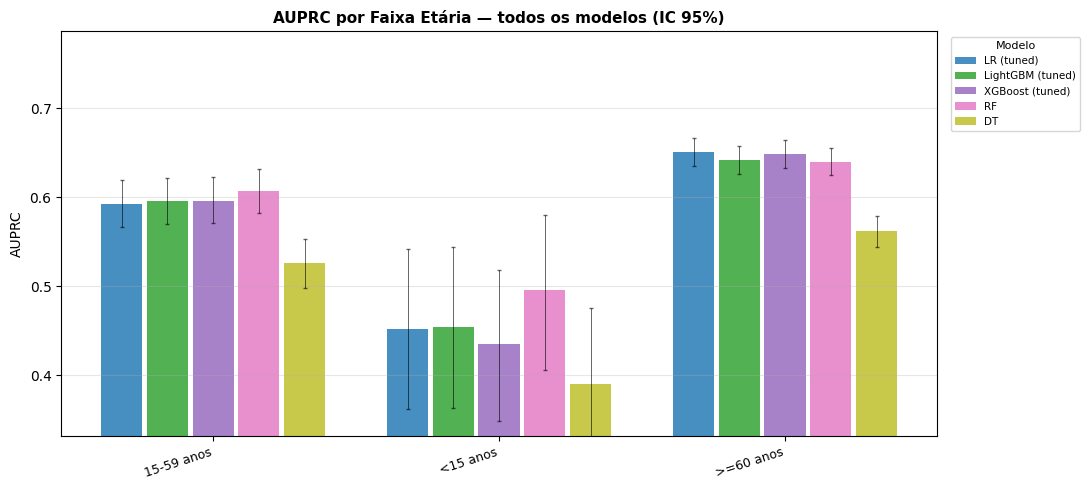

Gráfico salvo: ../../output/plots/fairness_01_faixa_etaria_auprc.png


In [7]:
# Gráfico de barras agrupadas — AUPRC por faixa etária
grafico_auprc(df_sec_idade,
              'AUPRC por Faixa Etária — todos os modelos (IC 95%)',
              'fairness_01_faixa_etaria_auprc.png')

In [8]:
# Identificar disparidades > 0.05
df_disp_idade = alertas_disparidade(df_sec_idade, 'Faixa Etária')
_disparidades['Faixa Etária'] = df_disp_idade
display(df_disp_idade[['modelo','disparidade','auprc_max','subg_max','auprc_min','subg_min','flag']].round(4))

Limiar ΔAUPRC > 0.05 | 5 modelo(s) com alerta:
  ⚠️  XGBoost (tuned): ΔAUPRC = 0.2127  [>=60 anos (0.648) vs <15 anos (0.436)]
  ⚠️  LR (tuned): ΔAUPRC = 0.1984  [>=60 anos (0.651) vs <15 anos (0.452)]
  ⚠️  LightGBM (tuned): ΔAUPRC = 0.1882  [>=60 anos (0.642) vs <15 anos (0.454)]
  ⚠️  DT: ΔAUPRC = 0.1711  [>=60 anos (0.562) vs <15 anos (0.391)]
  ⚠️  RF: ΔAUPRC = 0.1444  [>=60 anos (0.640) vs <15 anos (0.495)]


,modelo,disparidade,auprc_max,subg_max,auprc_min,subg_min,flag
4,XGBoost (tuned),0.2127,0.6484,>=60 anos,0.4357,<15 anos,ALERTA
1,LR (tuned),0.1984,0.6508,>=60 anos,0.4524,<15 anos,ALERTA
2,LightGBM (tuned),0.1882,0.6424,>=60 anos,0.4542,<15 anos,ALERTA
0,DT,0.1711,0.5617,>=60 anos,0.3906,<15 anos,ALERTA
3,RF,0.1444,0.6399,>=60 anos,0.4955,<15 anos,ALERTA


## 2. Sexo (CS_SEXO)

Diferenças fisiológicas e de comportamento de saúde entre homens e mulheres podem
se refletir na apresentação clínica da dengue e, consequentemente, na performance
dos modelos. Além disso, variáveis como `CS_GESTANT` são informativas apenas para
mulheres, criando assimetria nas features entre sexos.

Um modelo com disparidade por sexo pode, por exemplo, subestimar risco em homens
por não apresentar variáveis de gestação preenchidas (valor = 6 / "não se aplica"),
criando um padrão que o modelo associa a menor risco.

**Grupos:** Feminino · Masculino

In [9]:
# Criar grupos de sexo
df_test['sexo_grupo'] = df_test['CS_SEXO'].map({'F': 'Feminino', 'M': 'Masculino'})

tab_sexo = (df_test
    .groupby('sexo_grupo')
    .agg(n=('y_true','count'), eventos=('y_true','sum'), taxa=('y_true','mean'))
    .assign(pct_total=lambda d: (d['n'] / d['n'].sum() * 100).round(1))
    .round({'taxa': 4}))
display(tab_sexo)

,n,eventos,taxa,pct_total
sexo_grupo,,,,
Feminino,87764,2667.0,0.0304,54.7
Masculino,72672,2626.0,0.0361,45.3


In [10]:
print('Calculando métricas por sexo...')
df_sec_sexo = calcular_secao(df_test, 'sexo_grupo', 'CS_SEXO')
print(f'\nConcluído: {len(df_sec_sexo)} linhas de resultados.')

Calculando métricas por sexo...
  Subgrupo 'Feminino': n=87,764, eventos=2667 ... OK
  Subgrupo 'Masculino': n=72,672, eventos=2626 ... OK

Concluído: 10 linhas de resultados.


In [11]:
print('=== AUPRC (IC 95%) por Sexo ===\n')
display(tabela_ic(df_sec_sexo, 'auprc'))

print('\n=== Sensibilidade (IC 95%) por Sexo ===')
display(tabela_ic(df_sec_sexo, 'sensibilidade'))

print('\n=== Tabela completa ===')
display(df_sec_sexo[cols_show].round(4).sort_values(['subgrupo','modelo']).reset_index(drop=True))

=== AUPRC (IC 95%) por Sexo ===



,Feminino,Masculino
LR (tuned),0.626 (0.606–0.645),0.625 (0.606–0.644)
LightGBM (tuned),0.626 (0.607–0.644),0.627 (0.609–0.645)
XGBoost (tuned),0.627 (0.607–0.645),0.631 (0.612–0.649)
RF,0.633 (0.613–0.650),0.624 (0.605–0.642)
DT,0.547 (0.525–0.567),0.557 (0.538–0.577)



=== Sensibilidade (IC 95%) por Sexo ===


,Feminino,Masculino
LR (tuned),0.809 (0.794–0.824),0.817 (0.802–0.832)
LightGBM (tuned),0.744 (0.727–0.759),0.754 (0.737–0.770)
XGBoost (tuned),0.789 (0.775–0.804),0.799 (0.782–0.814)
RF,0.629 (0.611–0.647),0.618 (0.600–0.636)
DT,0.744 (0.728–0.761),0.734 (0.717–0.751)



=== Tabela completa ===


,subgrupo,modelo,n_total,n_eventos,auprc,auprc_ci_low,auprc_ci_high,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensibilidade,sens_ci_low,sens_ci_high,especificidade,esp_ci_low,esp_ci_high
0,Feminino,DT,87764,2667,0.5473,0.5252,0.5672,0.8720,0.8626,0.8811,0.7443,0.7281,0.7606,0.9019,0.8999,0.9039
1,Feminino,LR (tuned),87764,2667,0.6257,0.6057,0.6448,0.9213,0.9151,0.9271,0.8089,0.7941,0.8235,0.8773,0.8752,0.8795
2,Feminino,LightGBM (tuned),87764,2667,0.6263,0.6066,0.6440,0.9074,0.9002,0.9140,0.7438,0.7270,0.7594,0.9269,0.9252,0.9286
3,Feminino,RF,87764,2667,0.6327,0.6127,0.6504,0.9173,0.9109,0.9234,0.6291,0.6105,0.6467,0.9860,0.9852,0.9868
4,Feminino,XGBoost (tuned),87764,2667,0.6274,0.6074,0.6454,0.9145,0.9077,0.9209,0.7895,0.7748,0.8042,0.8920,0.8900,0.8941
5,Masculino,DT,72672,2626,0.5575,0.5375,0.5772,0.8802,0.8713,0.8893,0.7341,0.7174,0.7506,0.9010,0.8987,0.9031
6,Masculino,LR (tuned),72672,2626,0.6254,0.6059,0.6444,0.9255,0.9195,0.9309,0.8171,0.8020,0.8325,0.8677,0.8652,0.8703
7,Masculino,LightGBM (tuned),72672,2626,0.6268,0.6087,0.6452,0.9129,0.9060,0.9190,0.7537,0.7368,0.7702,0.9119,0.9098,0.9140
8,Masculino,RF,72672,2626,0.6236,0.6050,0.6418,0.9211,0.9149,0.9270,0.6183,0.6003,0.6361,0.9802,0.9793,0.9812
9,Masculino,XGBoost (tuned),72672,2626,0.6310,0.6125,0.6494,0.9200,0.9136,0.9257,0.7985,0.7820,0.8141,0.8778,0.8753,0.8803


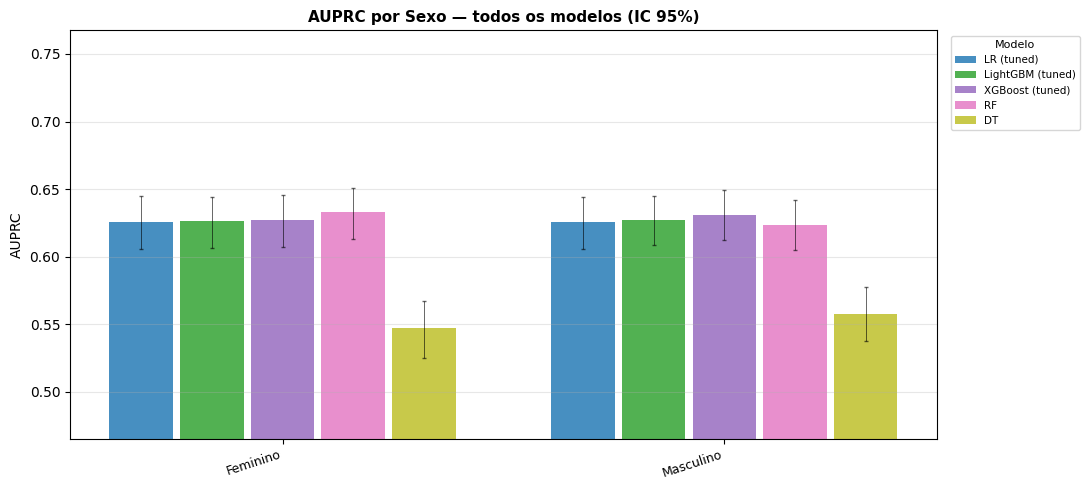

Gráfico salvo: ../../output/plots/fairness_02_sexo_auprc.png


In [12]:
grafico_auprc(df_sec_sexo,
              'AUPRC por Sexo — todos os modelos (IC 95%)',
              'fairness_02_sexo_auprc.png')

In [13]:
df_disp_sexo = alertas_disparidade(df_sec_sexo, 'Sexo')
_disparidades['Sexo'] = df_disp_sexo
display(df_disp_sexo[['modelo','disparidade','auprc_max','subg_max','auprc_min','subg_min','flag']].round(4))

Limiar ΔAUPRC > 0.05 | 0 modelo(s) com alerta:
  Nenhum modelo excede o limiar.


,modelo,disparidade,auprc_max,subg_max,auprc_min,subg_min,flag
0,DT,0.0101,0.5575,Masculino,0.5473,Feminino,OK
3,RF,0.0091,0.6327,Feminino,0.6236,Masculino,OK
4,XGBoost (tuned),0.0036,0.6310,Masculino,0.6274,Feminino,OK
2,LightGBM (tuned),0.0006,0.6268,Masculino,0.6263,Feminino,OK
1,LR (tuned),0.0002,0.6257,Feminino,0.6254,Masculino,OK


## 3. Raça/Cor (CS_RACA)

Raça/cor é uma variável crítica na análise de equidade em saúde no Brasil.
Populações negras e pardas enfrentam maior exposição a determinantes sociais
adversos (moradia, acesso a serviços, escolaridade), o que pode influenciar
tanto a gravidade da dengue quanto a completude dos registros.

Vieses históricos no sistema de saúde podem resultar em modelos com performance
inferior para grupos raciais minoritários, perpetuando iniquidades existentes.

**Codificação SINAN:**
- 1 = Branca · 2 = Preta · 3 = Amarela · 4 = Parda · 5 = Indígena

> **Nota:** Raça Indígena (5) tem <30 eventos no conjunto de teste e será excluída.

In [14]:
# Mapear CS_RACA para rótulos legíveis
raca_map = {1.0: 'Branca', 2.0: 'Preta', 3.0: 'Amarela', 4.0: 'Parda', 5.0: 'Indigena'}
df_test['raca_grupo'] = df_test['CS_RACA'].map(raca_map)

tab_raca = (df_test
    .groupby('raca_grupo')
    .agg(n=('y_true','count'), eventos=('y_true','sum'), taxa=('y_true','mean'))
    .assign(pct_total=lambda d: (d['n'] / d['n'].sum() * 100).round(1))
    .round({'taxa': 4}))
print('Distribuição por raça/cor (subgrupos com <30 eventos serão excluídos):')
display(tab_raca)

Distribuição por raça/cor (subgrupos com <30 eventos serão excluídos):


,n,eventos,taxa,pct_total
raca_grupo,,,,
Amarela,1730,52.0,0.0301,1.2
Branca,77352,2840.0,0.0367,55.0
Indigena,411,14.0,0.0341,0.3
Parda,55697,1625.0,0.0292,39.6
Preta,5574,248.0,0.0445,4.0


In [15]:
print('Calculando métricas por raça/cor...')
df_sec_raca = calcular_secao(df_test, 'raca_grupo', 'CS_RACA')
print(f'\nConcluído: {len(df_sec_raca)} linhas de resultados.')

Calculando métricas por raça/cor...
  Subgrupo 'Amarela': n=1,730, eventos=52 ... OK
  Subgrupo 'Branca': n=77,352, eventos=2840 ... OK
  [EXCLUÍDO] CS_RACA = 'Indigena': apenas 14 eventos (< 30)
  Subgrupo 'Parda': n=55,697, eventos=1625 ... OK
  Subgrupo 'Preta': n=5,574, eventos=248 ... OK

Concluído: 20 linhas de resultados.


In [16]:
print('=== AUPRC (IC 95%) por Raça/Cor ===\n')
display(tabela_ic(df_sec_raca, 'auprc'))

print('\n=== Sensibilidade (IC 95%) por Raça/Cor ===')
display(tabela_ic(df_sec_raca, 'sensibilidade'))

print('\n=== Tabela completa ===')
display(df_sec_raca[cols_show].round(4).sort_values(['subgrupo','modelo']).reset_index(drop=True))

=== AUPRC (IC 95%) por Raça/Cor ===



,Amarela,Branca,Parda,Preta
LR (tuned),0.637 (0.501–0.763),0.634 (0.615–0.654),0.598 (0.571–0.624),0.645 (0.579–0.704)
LightGBM (tuned),0.649 (0.521–0.768),0.645 (0.626–0.664),0.588 (0.562–0.612),0.650 (0.589–0.706)
XGBoost (tuned),0.652 (0.522–0.774),0.648 (0.629–0.666),0.590 (0.563–0.616),0.644 (0.580–0.703)
RF,0.634 (0.505–0.754),0.642 (0.624–0.660),0.602 (0.576–0.627),0.661 (0.599–0.717)
DT,0.567 (0.416–0.709),0.562 (0.541–0.582),0.541 (0.514–0.566),0.541 (0.473–0.605)



=== Sensibilidade (IC 95%) por Raça/Cor ===


,Amarela,Branca,Parda,Preta
LR (tuned),0.864 (0.761–0.952),0.813 (0.798–0.828),0.790 (0.769–0.809),0.867 (0.823–0.908)
LightGBM (tuned),0.825 (0.712–0.923),0.768 (0.752–0.784),0.714 (0.691–0.735),0.782 (0.730–0.833)
XGBoost (tuned),0.865 (0.765–0.952),0.805 (0.790–0.820),0.775 (0.755–0.795),0.823 (0.772–0.869)
RF,0.652 (0.518–0.782),0.634 (0.616–0.652),0.596 (0.571–0.619),0.657 (0.597–0.715)
DT,0.826 (0.719–0.922),0.757 (0.742–0.773),0.712 (0.689–0.733),0.710 (0.649–0.766)



=== Tabela completa ===


,subgrupo,modelo,n_total,n_eventos,auprc,auprc_ci_low,auprc_ci_high,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensibilidade,sens_ci_low,sens_ci_high,especificidade,esp_ci_low,esp_ci_high
0,Amarela,DT,1730,52,0.5668,0.4165,0.7089,0.8984,0.8383,0.9491,0.8263,0.7193,0.9216,0.8825,0.8671,0.8973
1,Amarela,LR (tuned),1730,52,0.6368,0.5010,0.7635,0.9218,0.8717,0.9623,0.8644,0.7609,0.9524,0.7867,0.7672,0.8064
2,Amarela,LightGBM (tuned),1730,52,0.6487,0.5210,0.7678,0.9077,0.8477,0.9564,0.8248,0.7115,0.9231,0.8906,0.8749,0.9061
3,Amarela,RF,1730,52,0.6345,0.5050,0.7545,0.9171,0.8664,0.9591,0.6521,0.5178,0.7818,0.9809,0.9743,0.9874
4,Amarela,XGBoost (tuned),1730,52,0.6516,0.5221,0.7736,0.9229,0.8735,0.9632,0.8649,0.7647,0.9524,0.8424,0.8249,0.8606
5,Branca,DT,77352,2840,0.5616,0.5410,0.5818,0.8873,0.8795,0.8952,0.7573,0.7417,0.7733,0.8873,0.8851,0.8896
6,Branca,LR (tuned),77352,2840,0.6343,0.6150,0.6543,0.9218,0.9158,0.9276,0.8131,0.7985,0.8276,0.8587,0.8561,0.8611
7,Branca,LightGBM (tuned),77352,2840,0.6454,0.6265,0.6636,0.9141,0.9075,0.9206,0.7680,0.7520,0.7836,0.9038,0.9017,0.9060
8,Branca,RF,77352,2840,0.6421,0.6237,0.6604,0.9194,0.9135,0.9254,0.6342,0.6157,0.6516,0.9809,0.9799,0.9818
9,Branca,XGBoost (tuned),77352,2840,0.6483,0.6294,0.6664,0.9188,0.9125,0.9249,0.8053,0.7902,0.8200,0.8646,0.8621,0.8670


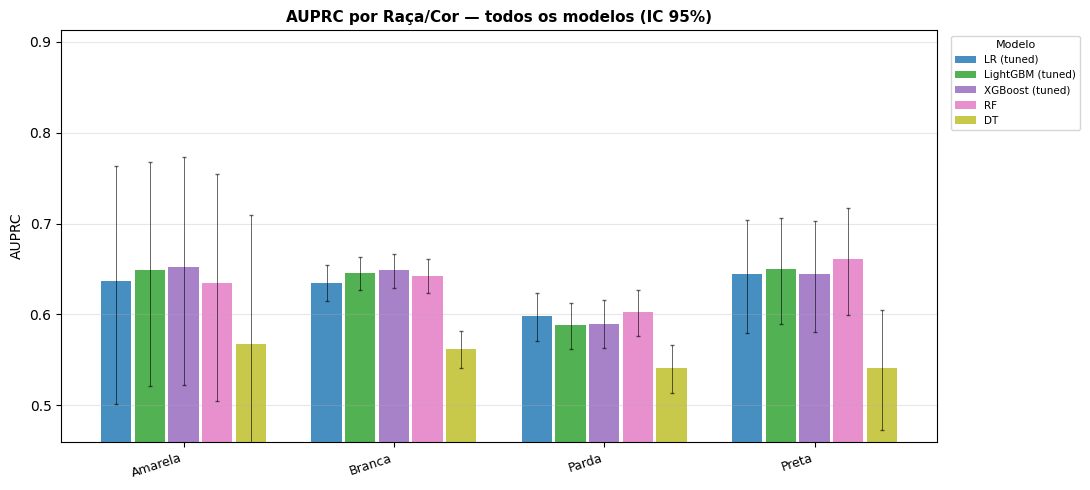

Gráfico salvo: ../../output/plots/fairness_03_raca_auprc.png


In [17]:
grafico_auprc(df_sec_raca,
              'AUPRC por Raça/Cor — todos os modelos (IC 95%)',
              'fairness_03_raca_auprc.png')

In [18]:
df_disp_raca = alertas_disparidade(df_sec_raca, 'Raca/Cor')
_disparidades['Raça/Cor'] = df_disp_raca
display(df_disp_raca[['modelo','disparidade','auprc_max','subg_max','auprc_min','subg_min','flag']].round(4))

Limiar ΔAUPRC > 0.05 | 3 modelo(s) com alerta:
  ⚠️  LightGBM (tuned): ΔAUPRC = 0.0620  [Preta (0.650) vs Parda (0.588)]
  ⚠️  XGBoost (tuned): ΔAUPRC = 0.0619  [Amarela (0.652) vs Parda (0.590)]
  ⚠️  RF: ΔAUPRC = 0.0588  [Preta (0.661) vs Parda (0.602)]


,modelo,disparidade,auprc_max,subg_max,auprc_min,subg_min,flag
2,LightGBM (tuned),0.0620,0.6500,Preta,0.5881,Parda,ALERTA
4,XGBoost (tuned),0.0619,0.6516,Amarela,0.5897,Parda,ALERTA
3,RF,0.0588,0.6610,Preta,0.6022,Parda,ALERTA
1,LR (tuned),0.0465,0.6446,Preta,0.5981,Parda,OK
0,DT,0.0261,0.5668,Amarela,0.5407,Preta,OK


## 4. Escolaridade (CS_ESCOL_N)

Escolaridade é proxy de condição socioeconômica e acesso a cuidados de saúde.
Indivíduos com menor escolaridade tendem a buscar atenção médica mais tardiamente,
com apresentações mais graves, o que pode alterar os padrões clínicos que o modelo
aprende para cada grupo.

Alta taxa de missings (51% no conjunto de teste) implica que modelos que dependem
desta variável podem apresentar performance diferenciada por grupo educacional.

**Agrupamento:**
| Grupo | Códigos SINAN |
|---|---|
| Sem/Fund. I | 0 (sem escolaridade) · 1 (Fund. I incomum.) · 2 (Fund. I compl.) |
| Fundamental II | 3 (Fund. II incomum.) · 4 (Fund. II compl.) |
| Médio | 5 (EM incompleto) · 6 (EM completo) |
| Superior | 7 (Superior incompl.) · 8 (Superior compl.) |
| Não se aplica | 10 (≤ 7 anos de idade) |

In [19]:
# Agrupar CS_ESCOL_N em faixas de maior poder estatístico
escol_grupo_map = {
    0.0:  'Sem/Fund.I',   # Sem escolaridade a Fund. I completo
    1.0:  'Sem/Fund.I',
    2.0:  'Sem/Fund.I',
    3.0:  'Fund.II',      # Fund. II incompleto e completo
    4.0:  'Fund.II',
    5.0:  'Médio',        # Ensino Médio incompleto e completo
    6.0:  'Médio',
    7.0:  'Superior',     # Superior incompleto e completo
    8.0:  'Superior',
    10.0: 'N/A (<8 anos)',# Não se aplica por idade
}
df_test['escol_grupo'] = df_test['CS_ESCOL_N'].map(escol_grupo_map)

tab_escol = (df_test
    .groupby('escol_grupo')
    .agg(n=('y_true','count'), eventos=('y_true','sum'), taxa=('y_true','mean'))
    .assign(pct_total=lambda d: (d['n'] / d['n'].sum() * 100).round(1))
    .round({'taxa': 4}))
print(f'Registros com escolaridade ausente: {df_test["CS_ESCOL_N"].isna().sum():,} '
      f'({df_test["CS_ESCOL_N"].isna().mean()*100:.1f}%)')
display(tab_escol)

Registros com escolaridade ausente: 80,958 (50.4%)


,n,eventos,taxa,pct_total
escol_grupo,,,,
Fund.II,14957,604.0,0.0404,18.8
Médio,28945,763.0,0.0264,36.4
N/A (<8 anos),12894,95.0,0.0074,16.2
Sem/Fund.I,12605,763.0,0.0605,15.8
Superior,10175,242.0,0.0238,12.8


In [20]:
print('Calculando métricas por escolaridade...')
df_sec_escol = calcular_secao(df_test, 'escol_grupo', 'CS_ESCOL_N')
print(f'\nConcluído: {len(df_sec_escol)} linhas de resultados.')

Calculando métricas por escolaridade...
  Subgrupo 'Fund.II': n=14,957, eventos=604 ... OK
  Subgrupo 'Médio': n=28,945, eventos=763 ... OK
  Subgrupo 'N/A (<8 anos)': n=12,894, eventos=95 ... OK
  Subgrupo 'Sem/Fund.I': n=12,605, eventos=763 ... OK
  Subgrupo 'Superior': n=10,175, eventos=242 ... OK

Concluído: 25 linhas de resultados.


In [21]:
print('=== AUPRC (IC 95%) por Escolaridade ===\n')
display(tabela_ic(df_sec_escol, 'auprc'))

print('\n=== Especificidade (IC 95%) por Escolaridade ===')
display(tabela_ic(df_sec_escol, 'especificidade'))

print('\n=== Tabela completa ===')
display(df_sec_escol[cols_show].round(4).sort_values(['subgrupo','modelo']).reset_index(drop=True))

=== AUPRC (IC 95%) por Escolaridade ===



,Fund.II,Médio,N/A (<8 anos),Sem/Fund.I,Superior
LR (tuned),0.680 (0.642–0.716),0.615 (0.578–0.651),0.404 (0.295–0.516),0.648 (0.612–0.681),0.632 (0.564–0.698)
LightGBM (tuned),0.684 (0.647–0.719),0.609 (0.571–0.644),0.385 (0.275–0.496),0.651 (0.615–0.685),0.651 (0.590–0.711)
XGBoost (tuned),0.685 (0.647–0.720),0.604 (0.565–0.640),0.383 (0.279–0.490),0.656 (0.621–0.689),0.635 (0.567–0.704)
RF,0.686 (0.648–0.720),0.618 (0.583–0.653),0.438 (0.329–0.551),0.649 (0.614–0.681),0.636 (0.569–0.702)
DT,0.626 (0.587–0.664),0.539 (0.502–0.576),0.318 (0.222–0.419),0.580 (0.543–0.616),0.534 (0.462–0.604)



=== Especificidade (IC 95%) por Escolaridade ===


,Fund.II,Médio,N/A (<8 anos),Sem/Fund.I,Superior
LR (tuned),0.854 (0.848–0.859),0.904 (0.901–0.908),0.988 (0.986–0.990),0.758 (0.750–0.765),0.902 (0.896–0.907)
LightGBM (tuned),0.920 (0.916–0.924),0.954 (0.951–0.956),0.988 (0.986–0.990),0.860 (0.854–0.866),0.974 (0.971–0.977)
XGBoost (tuned),0.881 (0.876–0.886),0.929 (0.926–0.932),0.983 (0.980–0.985),0.791 (0.784–0.799),0.952 (0.948–0.957)
RF,0.984 (0.982–0.986),0.987 (0.985–0.988),0.994 (0.993–0.996),0.980 (0.978–0.983),0.990 (0.988–0.992)
DT,0.896 (0.891–0.901),0.923 (0.920–0.927),0.974 (0.971–0.977),0.824 (0.817–0.830),0.933 (0.928–0.938)



=== Tabela completa ===


,subgrupo,modelo,n_total,n_eventos,auprc,auprc_ci_low,auprc_ci_high,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensibilidade,sens_ci_low,sens_ci_high,especificidade,esp_ci_low,esp_ci_high
0,Fund.II,DT,14957,604,0.6259,0.5875,0.6642,0.8908,0.8736,0.9088,0.7578,0.7249,0.7922,0.8960,0.8908,0.9008
1,Fund.II,LR (tuned),14957,604,0.6802,0.6419,0.7164,0.9327,0.9215,0.9438,0.8462,0.8170,0.8735,0.8539,0.8484,0.8594
2,Fund.II,LightGBM (tuned),14957,604,0.6838,0.6469,0.7186,0.9242,0.9116,0.9361,0.7685,0.7353,0.8010,0.9199,0.9155,0.9242
3,Fund.II,RF,14957,604,0.6857,0.6481,0.7203,0.9287,0.9163,0.9405,0.6655,0.6294,0.7030,0.9839,0.9818,0.9859
4,Fund.II,XGBoost (tuned),14957,604,0.6851,0.6475,0.7202,0.9291,0.9168,0.9408,0.8166,0.7868,0.8466,0.8808,0.8755,0.8858
5,Médio,DT,28945,763,0.5385,0.5016,0.5759,0.8742,0.8570,0.8905,0.7179,0.6855,0.7493,0.9235,0.9203,0.9267
6,Médio,LR (tuned),28945,763,0.6148,0.5779,0.6508,0.9147,0.9020,0.9268,0.7664,0.7358,0.7951,0.9042,0.9009,0.9077
7,Médio,LightGBM (tuned),28945,763,0.6091,0.5711,0.6438,0.9044,0.8915,0.9174,0.7073,0.6750,0.7384,0.9536,0.9512,0.9560
8,Médio,RF,28945,763,0.6182,0.5828,0.6534,0.9129,0.9001,0.9252,0.6325,0.5977,0.6658,0.9868,0.9854,0.9881
9,Médio,XGBoost (tuned),28945,763,0.6036,0.5647,0.6401,0.9110,0.8983,0.9233,0.7509,0.7202,0.7809,0.9292,0.9263,0.9322


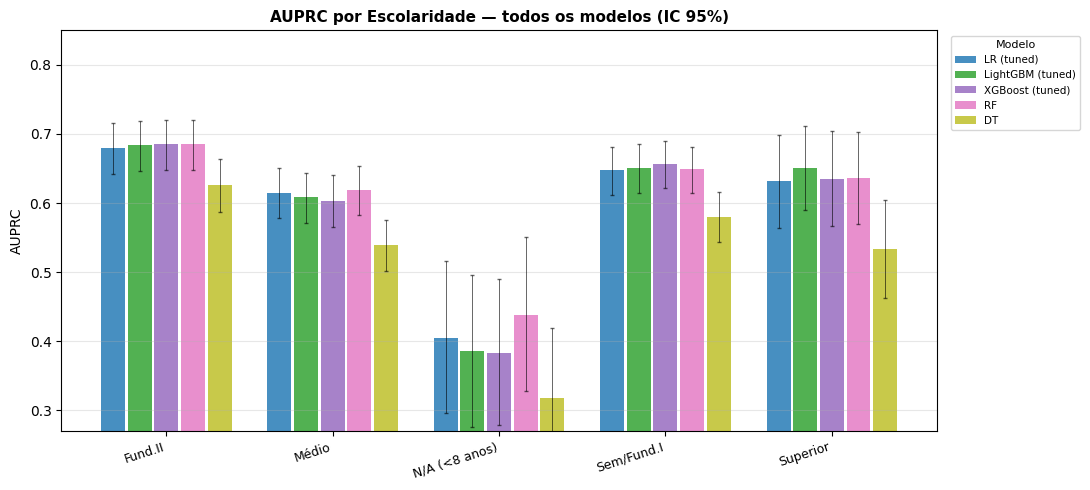

Gráfico salvo: ../../output/plots/fairness_04_escolaridade_auprc.png


In [22]:
grafico_auprc(df_sec_escol,
              'AUPRC por Escolaridade — todos os modelos (IC 95%)',
              'fairness_04_escolaridade_auprc.png')

In [23]:
df_disp_escol = alertas_disparidade(df_sec_escol, 'Escolaridade')
_disparidades['Escolaridade'] = df_disp_escol
display(df_disp_escol[['modelo','disparidade','auprc_max','subg_max','auprc_min','subg_min','flag']].round(4))

Limiar ΔAUPRC > 0.05 | 5 modelo(s) com alerta:
  ⚠️  DT: ΔAUPRC = 0.3078  [Fund.II (0.626) vs N/A (<8 anos) (0.318)]
  ⚠️  XGBoost (tuned): ΔAUPRC = 0.3020  [Fund.II (0.685) vs N/A (<8 anos) (0.383)]
  ⚠️  LightGBM (tuned): ΔAUPRC = 0.2984  [Fund.II (0.684) vs N/A (<8 anos) (0.385)]
  ⚠️  LR (tuned): ΔAUPRC = 0.2763  [Fund.II (0.680) vs N/A (<8 anos) (0.404)]
  ⚠️  RF: ΔAUPRC = 0.2473  [Fund.II (0.686) vs N/A (<8 anos) (0.438)]


,modelo,disparidade,auprc_max,subg_max,auprc_min,subg_min,flag
0,DT,0.3078,0.6259,Fund.II,0.3181,N/A (<8 anos),ALERTA
4,XGBoost (tuned),0.3020,0.6851,Fund.II,0.3831,N/A (<8 anos),ALERTA
2,LightGBM (tuned),0.2984,0.6838,Fund.II,0.3854,N/A (<8 anos),ALERTA
1,LR (tuned),0.2763,0.6802,Fund.II,0.4039,N/A (<8 anos),ALERTA
3,RF,0.2473,0.6857,Fund.II,0.4384,N/A (<8 anos),ALERTA


## 5. Gestação (CS_GESTANT)

Gestação modifica o risco de dengue grave: imunossupressão relativa, alterações
hemodinâmicas e maior risco de dengue hemorrágica tornam gestantes um grupo
clínico diferenciado. A presença de variáveis relacionadas à gestação no modelo
pode introduzir disparidade sistemática.

**Codificação SINAN:**
- 1–3 = Gestante (1°, 2°, 3° trimestre)
- 4 = Gestante (trimestre ignorado)
- 5 = Não gestante
- 6 = Não se aplica (sexo masculino / < 9 anos)

> **Nota:** O grupo "Gestante" (códigos 1–4 combinados, n ≈ 2.903) apresenta
> apenas **27 eventos** no conjunto de teste 2024 — insuficiente para estimativas
> confiáveis (< 30). Este grupo será excluído automaticamente.
> A análise compara "Não gestante" vs "Não se aplica" (proxy masculino).

In [24]:
# # Agrupar CS_GESTANT
# gestant_map = {
#     1.0: 'Gestante',         # 1° trimestre
#     2.0: 'Gestante',         # 2° trimestre
#     3.0: 'Gestante',         # 3° trimestre
#     4.0: 'Gestante',         # trimestre ignorado
#     5.0: 'Não gestante',     # não gestante
#     6.0: 'Não se aplica',    # masculino / < 9 anos
# }
# df_test['gestant_grupo'] = df_test['CS_GESTANT'].map(gestant_map)

# tab_gestant = (df_test
#     .groupby('gestant_grupo')
#     .agg(n=('y_true','count'), eventos=('y_true','sum'), taxa=('y_true','mean'))
#     .assign(pct_total=lambda d: (d['n'] / d['n'].sum() * 100).round(1))
#     .round({'taxa': 4}))
# display(tab_gestant)
# print('\nNota: grupos com <30 eventos serão excluídos automaticamente na análise.')

In [25]:
# print('Calculando métricas por situação de gestação...')
# df_sec_gestant = calcular_secao(df_test, 'gestant_grupo', 'CS_GESTANT')
# print(f'\nConcluído: {len(df_sec_gestant)} linhas de resultados.')

In [26]:
# print('=== AUPRC (IC 95%) por Gestação ===\n')
# display(tabela_ic(df_sec_gestant, 'auprc'))

# print('\n=== Sensibilidade (IC 95%) por Gestação ===')
# display(tabela_ic(df_sec_gestant, 'sensibilidade'))

# print('\n=== Tabela completa ===')
# display(df_sec_gestant[cols_show].round(4).sort_values(['subgrupo','modelo']).reset_index(drop=True))

In [27]:
# grafico_auprc(df_sec_gestant,
#               'AUPRC por Situação de Gestação — todos os modelos (IC 95%)',
#               'fairness_05_gestacao_auprc.png')

In [28]:
# df_disp_gestant = alertas_disparidade(df_sec_gestant, 'Gestação')
# _disparidades['Gestação'] = df_disp_gestant
# display(df_disp_gestant[['modelo','disparidade','auprc_max','subg_max','auprc_min','subg_min','flag']].round(4))

## 6. Região Geográfica (SG_UF → Região)

A dengue no Brasil apresenta padrões epidemiológicos distintos entre regiões,
influenciados por sorotipo circulante, cobertura de serviços de saúde, perfil
etário e condições socioeconômicas regionais. Um modelo treinado com dados de
todo o país pode ter performance desigual entre regiões se o padrão clínico de
desfecho grave difere substancialmente.

A região Sudeste (SP, RJ, MG, ES) concentra a maior parte do conjunto de treino,
o que pode penalizar regiões com distribuição clínica diferente, especialmente
Norte e Centro-Oeste.

**Mapeamento UF → Região (IBGE):**
- Norte: RO, AC, AM, RR, PA, AP, TO (códigos 11–17)
- Nordeste: MA, PI, CE, RN, PB, PE, AL, SE, BA (21–29)
- Sudeste: MG, ES, RJ, SP (31, 32, 33, 35)
- Sul: PR, SC, RS (41–43)
- Centro-Oeste: MS, MT, GO, DF (50–53)

In [29]:
# Mapear código IBGE de UF para macrorregião
regiao_map = {
    '11':'Norte', '12':'Norte', '13':'Norte', '14':'Norte',
    '15':'Norte', '16':'Norte', '17':'Norte',
    '21':'Nordeste', '22':'Nordeste', '23':'Nordeste', '24':'Nordeste',
    '25':'Nordeste', '26':'Nordeste', '27':'Nordeste', '28':'Nordeste', '29':'Nordeste',
    '31':'Sudeste', '32':'Sudeste', '33':'Sudeste', '35':'Sudeste',
    '41':'Sul', '42':'Sul', '43':'Sul',
    '50':'Centro-Oeste', '51':'Centro-Oeste', '52':'Centro-Oeste', '53':'Centro-Oeste',
}
df_test['regiao'] = df_test['SG_UF'].map(regiao_map)

tab_regiao = (df_test
    .groupby('regiao')
    .agg(n=('y_true','count'), eventos=('y_true','sum'), taxa=('y_true','mean'))
    .assign(pct_total=lambda d: (d['n'] / d['n'].sum() * 100).round(1))
    .round({'taxa': 4}))
display(tab_regiao)

,n,eventos,taxa,pct_total
regiao,,,,
Centro-Oeste,25416,824.0,0.0324,15.8
Nordeste,13365,231.0,0.0173,8.3
Norte,2639,37.0,0.0140,1.6
Sudeste,82718,3077.0,0.0372,51.5
Sul,36396,1126.0,0.0309,22.7


In [30]:
print('Calculando métricas por região geográfica...')
df_sec_regiao = calcular_secao(df_test, 'regiao', 'SG_UF_regiao')
print(f'\nConcluído: {len(df_sec_regiao)} linhas de resultados.')

Calculando métricas por região geográfica...
  Subgrupo 'Centro-Oeste': n=25,416, eventos=824 ... OK
  Subgrupo 'Nordeste': n=13,365, eventos=231 ... OK
  Subgrupo 'Norte': n=2,639, eventos=37 ... OK
  Subgrupo 'Sudeste': n=82,718, eventos=3077 ... OK
  Subgrupo 'Sul': n=36,396, eventos=1126 ... OK

Concluído: 25 linhas de resultados.


In [31]:
print('=== AUPRC (IC 95%) por Região ===\n')
display(tabela_ic(df_sec_regiao, 'auprc'))

print('\n=== Sensibilidade (IC 95%) por Região ===')
display(tabela_ic(df_sec_regiao, 'sensibilidade'))

print('\n=== Tabela completa ===')
display(df_sec_regiao[cols_show].round(4).sort_values(['subgrupo','modelo']).reset_index(drop=True))

=== AUPRC (IC 95%) por Região ===



,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
LR (tuned),0.655 (0.621–0.687),0.549 (0.477–0.612),0.611 (0.448–0.757),0.623 (0.605–0.642),0.639 (0.606–0.669)
LightGBM (tuned),0.640 (0.603–0.676),0.526 (0.450–0.595),0.587 (0.408–0.744),0.624 (0.607–0.643),0.660 (0.632–0.687)
XGBoost (tuned),0.636 (0.600–0.671),0.540 (0.468–0.607),0.609 (0.433–0.761),0.630 (0.612–0.649),0.658 (0.629–0.686)
RF,0.667 (0.634–0.701),0.565 (0.493–0.630),0.617 (0.446–0.758),0.618 (0.600–0.635),0.664 (0.636–0.691)
DT,0.560 (0.520–0.597),0.481 (0.410–0.552),0.434 (0.254–0.600),0.549 (0.530–0.569),0.574 (0.544–0.604)



=== Sensibilidade (IC 95%) por Região ===


,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
LR (tuned),0.828 (0.802–0.852),0.766 (0.711–0.818),0.865 (0.742–0.971),0.811 (0.796–0.825),0.817 (0.793–0.838)
LightGBM (tuned),0.672 (0.640–0.704),0.688 (0.626–0.744),0.730 (0.581–0.867),0.770 (0.756–0.785),0.760 (0.735–0.785)
XGBoost (tuned),0.726 (0.695–0.758),0.775 (0.720–0.828),0.811 (0.676–0.930),0.815 (0.801–0.829),0.792 (0.768–0.815)
RF,0.600 (0.565–0.634),0.566 (0.502–0.629),0.647 (0.487–0.800),0.624 (0.607–0.641),0.652 (0.624–0.680)
DT,0.674 (0.642–0.706),0.710 (0.652–0.767),0.597 (0.436–0.750),0.747 (0.731–0.762),0.779 (0.755–0.803)



=== Tabela completa ===


,subgrupo,modelo,n_total,n_eventos,auprc,auprc_ci_low,auprc_ci_high,roc_auc,roc_auc_ci_low,roc_auc_ci_high,sensibilidade,sens_ci_low,sens_ci_high,especificidade,esp_ci_low,esp_ci_high
0,Centro-Oeste,DT,25416,824,0.5596,0.5205,0.5967,0.8200,0.7974,0.8417,0.6737,0.6419,0.7057,0.9491,0.9465,0.9518
1,Centro-Oeste,LR (tuned),25416,824,0.6552,0.6211,0.6874,0.9390,0.9293,0.9480,0.8276,0.8022,0.8521,0.9191,0.9155,0.9224
2,Centro-Oeste,LightGBM (tuned),25416,824,0.6401,0.6030,0.6758,0.9191,0.9076,0.9304,0.6722,0.6398,0.7044,0.9790,0.9772,0.9807
3,Centro-Oeste,RF,25416,824,0.6675,0.6340,0.7011,0.9365,0.9263,0.9458,0.5996,0.5651,0.6338,0.9927,0.9916,0.9937
4,Centro-Oeste,XGBoost (tuned),25416,824,0.6364,0.6003,0.6715,0.9269,0.9163,0.9373,0.7257,0.6951,0.7579,0.9644,0.9620,0.9666
5,Nordeste,DT,13365,231,0.4811,0.4105,0.5524,0.8599,0.8248,0.8931,0.7102,0.6520,0.7671,0.9408,0.9367,0.9447
6,Nordeste,LR (tuned),13365,231,0.5488,0.4770,0.6122,0.9182,0.8963,0.9387,0.7662,0.7112,0.8182,0.9236,0.9192,0.9280
7,Nordeste,LightGBM (tuned),13365,231,0.5258,0.4496,0.5945,0.9128,0.8883,0.9349,0.6877,0.6265,0.7438,0.9684,0.9654,0.9713
8,Nordeste,RF,13365,231,0.5653,0.4930,0.6303,0.9202,0.8970,0.9407,0.5665,0.5023,0.6287,0.9920,0.9904,0.9935
9,Nordeste,XGBoost (tuned),13365,231,0.5401,0.4683,0.6067,0.9176,0.8935,0.9391,0.7747,0.7202,0.8279,0.9387,0.9348,0.9428


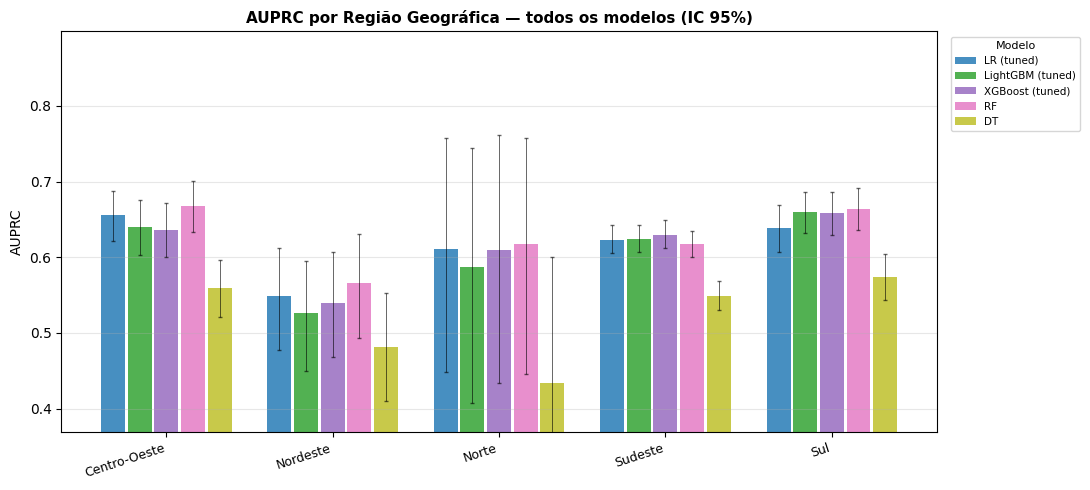

Gráfico salvo: ../../output/plots/fairness_06_regiao_auprc.png


In [32]:
grafico_auprc(df_sec_regiao,
              'AUPRC por Região Geográfica — todos os modelos (IC 95%)',
              'fairness_06_regiao_auprc.png')

In [33]:
df_disp_regiao = alertas_disparidade(df_sec_regiao, 'Região')
_disparidades['Região'] = df_disp_regiao
display(df_disp_regiao[['modelo','disparidade','auprc_max','subg_max','auprc_min','subg_min','flag']].round(4))

Limiar ΔAUPRC > 0.05 | 5 modelo(s) com alerta:
  ⚠️  DT: ΔAUPRC = 0.1404  [Sul (0.574) vs Norte (0.434)]
  ⚠️  LightGBM (tuned): ΔAUPRC = 0.1343  [Sul (0.660) vs Nordeste (0.526)]
  ⚠️  XGBoost (tuned): ΔAUPRC = 0.1181  [Sul (0.658) vs Nordeste (0.540)]
  ⚠️  LR (tuned): ΔAUPRC = 0.1064  [Centro-Oeste (0.655) vs Nordeste (0.549)]
  ⚠️  RF: ΔAUPRC = 0.1022  [Centro-Oeste (0.667) vs Nordeste (0.565)]


,modelo,disparidade,auprc_max,subg_max,auprc_min,subg_min,flag
0,DT,0.1404,0.5745,Sul,0.4340,Norte,ALERTA
2,LightGBM (tuned),0.1343,0.6602,Sul,0.5258,Nordeste,ALERTA
4,XGBoost (tuned),0.1181,0.6582,Sul,0.5401,Nordeste,ALERTA
1,LR (tuned),0.1064,0.6552,Centro-Oeste,0.5488,Nordeste,ALERTA
3,RF,0.1022,0.6675,Centro-Oeste,0.5653,Nordeste,ALERTA


## Seção Final — Síntese de Fairness

Consolida as maiores disparidades de AUPRC (Δ = max − min entre subgrupos) por
variável de estratificação e por modelo. Células vermelhas no heatmap indicam
ΔAUPRC > 0,05 (limiar de alerta).

In [34]:
# Tabela resumo: maior disparidade por variável × modelo
rows_resumo = []
for var, df_disp in _disparidades.items():
    for _, r in df_disp.iterrows():
        rows_resumo.append({
            'variavel':   var,
            'modelo':     r['modelo'],
            'disparidade': r['disparidade'],
            'flag':        r['flag'],
        })

df_resumo = pd.DataFrame(rows_resumo)

# Pivotar: linhas=modelo, colunas=variável
pivot_disp = df_resumo.pivot_table(index='modelo', columns='variavel',
                                    values='disparidade', aggfunc='first')

print('=== Disparidade AUPRC (Δmax−min) por Modelo × Variável ===\n')
display(pivot_disp.round(4).style
    .background_gradient(cmap='YlOrRd', vmin=0, vmax=0.15)
    .format('{:.4f}')
    .set_caption('Vermelho = maior disparidade | Limiar de alerta: 0.05'))

# Contar alertas por variável
print('\n=== Contagem de alertas (ΔAUPRC > 0.05) por variável ===')
alertas_por_var = (df_resumo[df_resumo['flag']=='ALERTA']
    .groupby('variavel').size()
    .rename('n_modelos_alertados')
    .to_frame())
display(alertas_por_var)

# Variável com maior dispersão média
print('\n=== Variável com maior disparidade média ===')
display(df_resumo.groupby('variavel')['disparidade']
    .agg(['mean','max','min'])
    .round(4)
    .sort_values('mean', ascending=False))

=== Disparidade AUPRC (Δmax−min) por Modelo × Variável ===



variavel,Escolaridade,Faixa Etária,Raça/Cor,Região,Sexo
modelo,,,,,
DT,0.3078,0.1711,0.0261,0.1404,0.0101
LR (tuned),0.2763,0.1984,0.0465,0.1064,0.0002
LightGBM (tuned),0.2984,0.1882,0.0620,0.1343,0.0006
RF,0.2473,0.1444,0.0588,0.1022,0.0091
XGBoost (tuned),0.3020,0.2127,0.0619,0.1181,0.0036



=== Contagem de alertas (ΔAUPRC > 0.05) por variável ===


,n_modelos_alertados
variavel,
Escolaridade,5
Faixa Etária,5
Raça/Cor,3
Região,5



=== Variável com maior disparidade média ===


,mean,max,min
variavel,,,
Escolaridade,0.2864,0.3078,0.2473
Faixa Etária,0.1830,0.2127,0.1444
Região,0.1203,0.1404,0.1022
Raça/Cor,0.0510,0.0620,0.0261
Sexo,0.0047,0.0101,0.0002


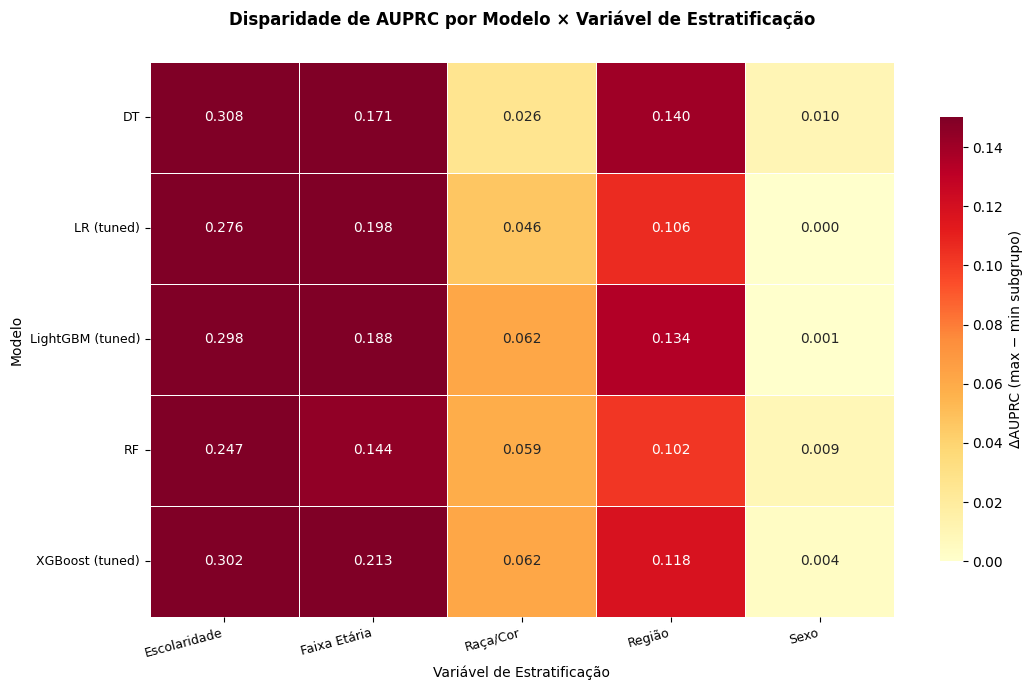

Heatmap salvo: ../../output/plots/fairness_heatmap_disparidades.png


In [35]:
# Heatmap: modelos × variáveis — magnitude da disparidade AUPRC
fig, ax = plt.subplots(figsize=(11, 7))

sns.heatmap(
    pivot_disp,
    annot=True, fmt='.3f', cmap='YlOrRd',
    vmin=0, vmax=0.15, linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'ΔAUPRC (max − min subgrupo)', 'shrink': 0.8},
)



ax.set_title('Disparidade de AUPRC por Modelo × Variável de Estratificação\n'
             ,
             fontweight='bold', fontsize=12, pad=12)
ax.set_xlabel('Variável de Estratificação', fontsize=10)
ax.set_ylabel('Modelo', fontsize=10)
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

path_heat = os.path.join(OUTPUT_PLT, 'fairness_heatmap_disparidades.png')
plt.savefig(path_heat, dpi=150, bbox_inches='tight')
plt.show()
print(f'Heatmap salvo: {path_heat}')

In [36]:
# Salvar tabela resumo como CSV
csv_path = os.path.join(OUTPUT_PLT, '..', 'metricas', 'fairness_disparidades_resumo.csv')
df_resumo.to_csv(csv_path, index=False)
print(f'Resumo salvo: {csv_path}')

# Salvar resultado completo de cada seção
for var, df_disp in _disparidades.items():
    slug = var.lower().replace('/', '_').replace(' ', '_')
    p = os.path.join(OUTPUT_PLT, '..', 'metricas', f'fairness_{slug}_detalhado.csv')
    df_disp.to_csv(p, index=False)
print('Resultados detalhados por variável salvos.')

Resumo salvo: ../../output/plots/../metricas/fairness_disparidades_resumo.csv
Resultados detalhados por variável salvos.


## Template — Seção de Limitações do Manuscrito

> **Instruções:** copie o bloco abaixo e substitua os marcadores `[VARIÁVEL]`,
> `[MODELO]` e `[VALOR]` com os resultados observados nas células anteriores.

---

**Equidade e limitações da generalização**

A análise de equidade estratificada revelou variações na capacidade preditiva dos
modelos entre subgrupos populacionais relevantes para a saúde pública brasileira.
Foram identificadas disparidades de AUPRC superiores a 0,05 na variável [VARIÁVEL],
particularmente evidentes no modelo [MODELO] (ΔAUPRC = [VALOR]; subgrupos:
[SUBGRUPO MELHOR], AUPRC = [VALOR] vs. [SUBGRUPO PIOR], AUPRC = [VALOR]).

As possíveis explicações para as disparidades observadas incluem: (i) diferenças
no tamanho amostral por subgrupo — subgrupos com menor representatividade apresentam
estimativas com maior incerteza e potencial viés, conforme evidenciado pelos
intervalos de confiança mais amplos; (ii) heterogeneidade na completude de registro
clínico entre grupos, uma vez que variáveis com elevada taxa de missings (e.g.,
`CS_ESCOL_N`: 51% ausente; `CS_RACA`: 12% ausente) podem introduzir viés sistemático
nos subgrupos que mais concentram dados faltantes; (iii) diferenças reais na
apresentação clínica da dengue grave entre populações, incluindo variações por
faixa etária, região geográfica e condição socioeconômica.

A performance dos modelos deve ser interpretada com cautela para os grupos
[GRUPOS EXCLUÍDOS POR INSUFICIÊNCIA AMOSTRAL], que não puderam ser avaliados
de forma confiável (< 30 eventos). Destaca-se especialmente a limitação para
gestantes e para a população indígena, grupos de reconhecida vulnerabilidade à
dengue grave, mas sub-representados no conjunto de dados de 2024.

Para implementação clínica, recomenda-se: (a) monitoramento prospectivo da
performance por subgrupo após implantação; (b) calibração local em contextos
geográficos com distribuição clínica distinta da Região Sudeste, que concentra
[X]% do conjunto de treino; e (c) revisão periódica da equidade conforme novos
dados epidemiológicos tornem-se disponíveis.